LOADDING DAN PELABELAN DATA


In [54]:
df = pd.read_csv('ulasan_tokopedia.csv')
df = df.dropna(subset=['content'])

df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,e6d61fee-2c32-449c-8a73-2f400563727e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sebagai pembeli, dbandingkan oren atau tiktok ...",5,0,3.360.0,2026-04-17 05:10:21,NaN,NaN,3.360.0
1,8e6bbd73-b1ec-4863-b32f-441ddbad18f3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,untuk sekarang sejak habis 4.4 .. mantab pokok...,5,2,3.356.0,2026-04-17 04:59:47,"Toppers, terima kasih atas rating yang kamu be...",2025-03-21 05:07:01,3.356.0
2,3644352f-8f79-4c1c-b3a9-bbba2a9af9de,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Jangan bayar buatlangganan PLUS, diskonnya mak...",1,3,3.359.0,2026-04-17 04:46:52,"Hi Toppers, terima kasih untuk rating dan ulas...",2025-01-20 13:07:11,3.359.0
3,f4f40ff4-139c-4358-a459-f56c80951fd2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,4,0,3.359.0,2026-04-17 04:35:19,NaN,NaN,3.359.0
4,07b538d7-5e49-4bc0-bf04-b34d0147c23d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"bug cok, transaksi ada 3, yg nongol cuman 1, t...",2,0,3.360.0,2026-04-17 04:05:41,NaN,NaN,3.360.0


Distribusi Label Sentimen:
label
positif    7636
negatif    6549
netral      815
Name: count, dtype: int64


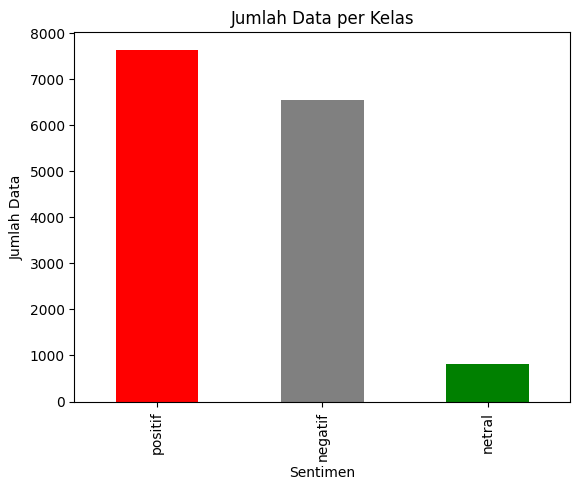

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Dataset
df = pd.read_csv('ulasan_tokopedia.csv')
df = df.dropna(subset=['content'])  # Hapus data kosong

# 2. Pelabelan 3 Kelas (Sesuai Kriteria)
def pilar_labeling(score):
    if score <= 2:
        return 'negatif'   # Negatif
    elif score == 3:
        return 'netral'    # Netral
    else:
        return 'positif'   # Positif

df['label'] = df['score'].apply(pilar_labeling)

# 3. Tampilkan Distribusi
print("Distribusi Label Sentimen:")
print(df['label'].value_counts())

# Plot
df['label'].value_counts().plot(kind='bar', title='Jumlah Data per Kelas', color=['red', 'gray', 'green'])
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Data')
plt.show()

In [56]:
from sklearn.utils import resample
target = len(df_positif)

# Oversampling negatif dan netral
df_negatif_upsampled = resample(df_negatif, replace=True, n_samples=target, random_state=42)
df_netral_upsampled = resample(df_netral, replace=True, n_samples=target, random_state=42)

# Gabungkan semua kelas
df_balanced = pd.concat([df_positif, df_negatif_upsampled, df_netral_upsampled])

# Cek distribusi setelah balancing
print("\nJumlah data setelah balancing:")
print(df_balanced['label'].value_counts())

# Gunakan df_balanced untuk tahap selanjutnya
df = df_balanced.copy()

print(f"\nTotal data setelah balancing: {len(df)}")


Jumlah data setelah balancing:
label
positif    7636
negatif    7636
netral     7636
Name: count, dtype: int64

Total data setelah balancing: 22908


In [57]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = text.strip()
    return text

# Buat content_clean dari kolom 'content'
df['content_clean'] = df['content'].apply(clean_text)

# Baru buat text_clean
df['text_clean'] = df['content_clean']

print("Kolom setelah dibuat:")
print(df.columns.tolist())

Kolom setelah dibuat:
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion', 'label', 'content_clean', 'text_clean']


In [58]:
import re

def clean_text(text):
    text = str(text).lower()  # Case folding
    text = re.sub(r'[^a-z\s]', '', text)  # Menghapus karakter khusus & angka
    text = text.strip()
    return text

# Gunakan kolom 'text_clean' (bukan 'content')
df['content_clean'] = df['text_clean'].apply(clean_text)

# Tampilkan tabel perbandingan
print("Tabel Perbandingan Hasil Preprocessing:")
display(df[['text_clean', 'content_clean']].head())

Tabel Perbandingan Hasil Preprocessing:


,text_clean,content_clean
0,sebagai pembeli dbandingkan oren atau tiktok s...,sebagai pembeli dbandingkan oren atau tiktok s...
1,untuk sekarang sejak habis mantab pokok nya ...,untuk sekarang sejak habis mantab pokok nya ...
3,good,good
7,toko pedia bakal jadi langganan ku mksih,toko pedia bakal jadi langganan ku mksih
8,mantaap,mantaap


Preprocessing Teks (Cleaning & Normalisasi)

In [59]:
# Cek semua kolom yang ada di df
print("Kolom yang tersedia:")
print(df.columns.tolist())

Kolom yang tersedia:
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion', 'label', 'content_clean', 'text_clean']


In [60]:
import re

def clean_text(text):
    text = str(text).lower()  # Case folding
    text = re.sub(r'[^a-z\s]', '', text)  # Menghapus karakter khusus & angka
    text = text.strip()
    return text

# Gunakan kolom 'text_clean' (bukan 'content')
df['content_clean'] = df['text_clean'].apply(clean_text)

# Tampilkan tabel perbandingan
print("Tabel Perbandingan Hasil Preprocessing:")
display(df[['text_clean', 'content_clean']].head())

Tabel Perbandingan Hasil Preprocessing:


,text_clean,content_clean
0,sebagai pembeli dbandingkan oren atau tiktok s...,sebagai pembeli dbandingkan oren atau tiktok s...
1,untuk sekarang sejak habis mantab pokok nya ...,untuk sekarang sejak habis mantab pokok nya ...
3,good,good
7,toko pedia bakal jadi langganan ku mksih,toko pedia bakal jadi langganan ku mksih
8,mantaap,mantaap


TOKENAZAITION DAN EXTRAKSI FITUR

In [61]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd

# Parameter
max_features = 10000
max_len = 100

# Inisialisasi Tokenizer
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(df['text_clean'].values)

# Transformasi teks ke angka
X = tokenizer.texts_to_sequences(df['text_clean'].values)
X = pad_sequences(X, maxlen=max_len)

# One-Hot Encoding untuk Label (3 Kelas)
y = pd.get_dummies(df['label']).values

print(f"Data siap! Total sampel: {X.shape[0]}")

Data siap! Total sampel: 22908


LATIH 3 MODEL SKEMA

In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Pembagian Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun Arsitektur Deep Learning (Double Bi-LSTM)
model_3 = Sequential([
    Embedding(max_features, 128, input_length=max_len),
    SpatialDropout1D(0.4),
    Bidirectional(LSTM(128, return_sequences=True)),
    Bidirectional(LSTM(64)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_3.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early Stopping: Berhenti otomatis jika akurasi tidak naik lagi
early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

print("Memulai pelatihan model pada 22.980 sampel...")
history_3 = model_3.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Memulai pelatihan model pada 22.980 sampel...
Epoch 1/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 228s 789ms/step - accuracy: 0.6710 - loss: 0.7535 - val_accuracy: 0.8121 - val_loss: 0.5282
Epoch 2/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 210s 759ms/step - accuracy: 0.8603 - loss: 0.4249 - val_accuracy: 0.8641 - val_loss: 0.3899
Epoch 3/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 267s 779ms/step - accuracy: 0.9047 - loss: 0.2975 - val_accuracy: 0.8844 - val_loss: 0.3490
Epoch 4/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 209s 754ms/step - accuracy: 0.9220 - loss: 0.2411 - val_accuracy: 0.8890 - val_loss: 0.3439
Epoch 5/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 264s 760ms/step - accuracy: 0.9331 - loss: 0.2061 - val_accuracy: 0.8973 - val_loss: 0.3384
Epoch 6/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 217s 783ms/step - accuracy: 0.9399 - loss: 0.1848 - val_accuracy: 0.9003 - val_loss: 0.3589
Epoch 7/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 256s 760ms/step - accuracy: 0.9451 - loss: 0.1686 - val_accuracy: 0.9032 - val_loss: 0.3735
Epoch 8/20
277/277 ━━━━━━━━━━━

VISUALISASI AKURASI DAN LOSS

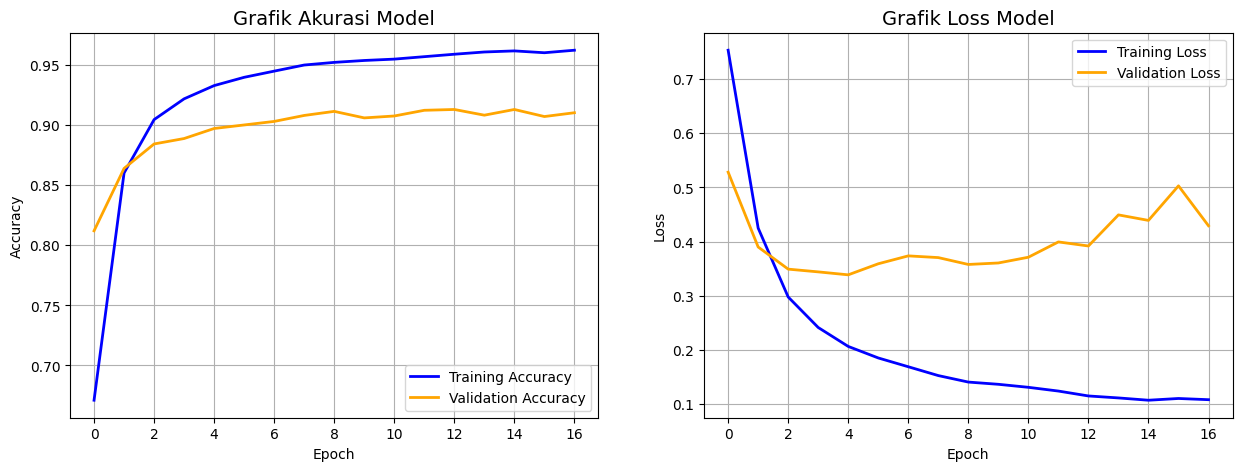

In [97]:
import matplotlib.pyplot as plt

# Membuat Grafik Akurasi & Loss
plt.figure(figsize=(15, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history_3.history['accuracy'], label='Training Accuracy', color='blue', lw=2)
plt.plot(history_3.history['val_accuracy'], label='Validation Accuracy', color='orange', lw=2)
plt.title('Grafik Akurasi Model', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_3.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history_3.history['val_loss'], label='Validation Loss', color='orange', lw=2)
plt.title('Grafik Loss Model', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# Plot Confusion Matrix

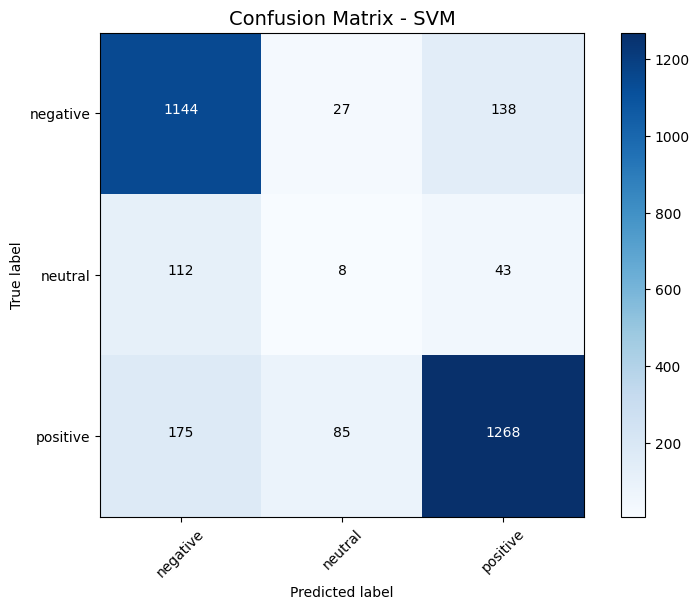

In [98]:

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - SVM', fontsize=14)
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)

# Tambahkan angka
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [99]:
# Fungsi untuk prediksi sentimen baru
def predict_sentiment(text, model, vectorizer, label_encoder):
    # Preprocessing
    text_clean = preprocess_pipeline(text)
    # Transform ke TF-IDF
    text_tfidf = vectorizer.transform([text_clean])
    # Prediksi
    pred = model.predict(text_tfidf)
    # Kembalikan label asli
    return label_encoder.inverse_transform(pred)[0]

# Contoh uji coba
test_texts = [
    "Aplikasinya bagus banget, pengiriman cepat!",
    "Payah, barang rusak dan lama sampai",
    "Standar saja, biasa aja gitu"
]


print("UJI COBA MODEL DENGAN KALIMAT BARU")


for text in test_texts:
    sentiment = predict_sentiment(text, best_svm, tfidf, le)
    print(f"Text: {text}")
    print(f"Sentimen: {sentiment}\n")

UJI COBA MODEL DENGAN KALIMAT BARU
Text: Aplikasinya bagus banget, pengiriman cepat!
Sentimen: positive

Text: Payah, barang rusak dan lama sampai
Sentimen: negative

Text: Standar saja, biasa aja gitu
Sentimen: positive

